# Funnel Analysis

In [103]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# loading processed data
df = pd.read_csv('../data/processed/patient_journey.csv')
df.head()

,Unnamed: 0,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,...,treatment_completed,follow_up_completed,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score
0,0,MTE-PAT-00001,2025-11-12 18:00:00,Thailand,40-49,Other/Not shared,Oncology,PVD-022,Phone,COORD-08,...,0,0,First Response,0,NaN,NaN,780855,0,0,NaN
1,1,MTE-PAT-00002,2025-04-12 04:00:00,Kenya,60+,Female,Fertility,PVD-022,WhatsApp,COORD-13,...,1,1,Follow-up,0,NaN,NaN,270529,270529,161988,7.7
2,2,MTE-PAT-00003,2025-12-28 06:00:00,Tanzania,50-59,Male,Oncology,PVD-008,Web Form,COORD-01,...,1,0,Treatment Completed,0,NaN,NaN,549181,549181,312857,7.4
3,3,MTE-PAT-00004,2025-08-31 21:00:00,Oman,40-49,Other/Not shared,Oncology,PVD-005,Phone,COORD-15,...,0,0,Consultation,1,Inquiry,Response delay,505922,0,0,NaN
4,4,MTE-PAT-00005,2025-08-26 18:00:00,Nepal,50-59,Male,Fertility,PVD-009,Phone,COORD-09,...,0,0,First Response,0,NaN,NaN,631722,0,0,NaN


In [5]:
print(df.sample(5))

      Unnamed: 0     patient_id         inquiry_date      country age_group  \
1225        1225  MTE-PAT-01226  2025-02-15 00:00:00     Tanzania       60+   
295          295  MTE-PAT-00296  2025-05-14 06:00:00        India     50-59   
227          227  MTE-PAT-00228  2025-04-29 09:00:00          UAE     30-39   
518          518  MTE-PAT-00519  2025-10-26 05:00:00      Nigeria     30-39   
1165        1165  MTE-PAT-01166  2025-11-05 05:00:00  Philippines       60+   

                gender     treatment_category provider_id       lead_source  \
1225  Other/Not shared                 Dental     PVD-018  Referral Partner   
295               Male       Cosmetic Surgery     PVD-023          WhatsApp   
227               Male      Bariatric Surgery     PVD-007          WhatsApp   
518   Other/Not shared                 Dental     PVD-021          Web Form   
1165              Male  Transplant Evaluation     PVD-018          Web Form   

     coordinator_id  ... treatment_completed follo

In [10]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.columns.to_list()

['patient_id',
 'inquiry_date',
 'country',
 'age_group',
 'gender',
 'treatment_category',
 'provider_id',
 'lead_source',
 'coordinator_id',
 'budget_band',
 'medical_urgency',
 'intent_score',
 'response_time_hours',
 'engagement_score',
 'consultation_booked',
 'quote_shared',
 'treatment_completed',
 'follow_up_completed',
 'current_stage',
 'drop_off_flag',
 'drop_off_stage',
 'reason_for_drop_off',
 'estimated_case_value_inr',
 'actual_revenue_inr',
 'service_cost_inr',
 'satisfaction_score']

In [11]:
df['drop_off_flag'].value_counts()

drop_off_flag
0    1150
1     350
Name: count, dtype: int64

In [12]:
df['drop_off_stage'].value_counts()

drop_off_stage
Inquiry            103
First Response      89
Consultation        55
Treatment Plan      49
Quote Shared        43
Travel Planning     11
Name: count, dtype: int64

In [20]:
df['drop_off_stage'].isnull().sum()

np.int64(1150)

In [31]:
df[df['drop_off_flag'] == 1]['drop_off_stage'].isnull().sum()

np.int64(0)

In [33]:
df[df['drop_off_stage'].notnull()]['drop_off_flag'].value_counts()

drop_off_flag
1    350
Name: count, dtype: int64

In [23]:
df['current_stage'].value_counts()

current_stage
First Response         415
Follow-up              312
Consultation           295
Treatment Completed    242
Quote Shared           236
Name: count, dtype: int64

In [19]:
df['current_stage'].isnull().sum()

np.int64(0)

### Funnel Stage

First Response -> Follow-up -> Consultation -> Treatment Completed -> Quote Shared

In [58]:
funnel_order = ['First Response','Consultation','Quote Shared','Follow-up','Treatment Completed']

funnel_counts = {
    'First Response' : len(df),
    'Consultation' : df['consultation_booked'].sum(),
    'Quote Shared' : df['quote_shared'].sum(),
    'Treatment Completed' : df['treatment_completed'].sum(),
    'Follow-up' : df['follow_up_completed'].sum()
}

In [59]:
df_funnel = pd.DataFrame(funnel_counts.items(),columns=['stage', 'patient_count'])

df_funnel

,stage,patient_count
0,First Response,1500
1,Consultation,984
2,Quote Shared,561
3,Treatment Completed,554
4,Follow-up,312


In [64]:
df_funnel['conversion_from_prev'] = df_funnel['patient_count']/df_funnel['patient_count'].shift(1)
df_funnel

,stage,patient_count,conversion_from_prev
0,First Response,1500,NaN
1,Consultation,984,0.656000
2,Quote Shared,561,0.570122
3,Treatment Completed,554,0.987522
4,Follow-up,312,0.563177


In [66]:
inquiries = len(df)
consultation_conversion_rate = df['consultation_booked'].sum()/inquiries
treatment_completion_rate = df['treatment_completed'].sum()/inquiries
quote_to_treatment_rate = df['treatment_completed'].sum()/df['quote_shared'].sum()

In [70]:
print(
    'consultation conversion rate : ', consultation_conversion_rate,
    'treatment completion rate : ', treatment_completion_rate,
    'quote to treatment rate : ', quote_to_treatment_rate,
sep='\n')

consultation conversion rate : 
0.656
treatment completion rate : 
0.36933333333333335
quote to treatment rate : 
0.9875222816399287


In [75]:
df_funnel['drop_off_count'] = df_funnel['patient_count'].shift(1) - df_funnel['patient_count']
df_funnel['drop_off_rate'] = df_funnel['patient_count']/df_funnel['patient_count'].shift(1)
df_funnel

,stage,patient_count,conversion_from_prev,drop_off_count,drop_off_rate
0,First Response,1500,NaN,NaN,NaN
1,Consultation,984,0.656000,516.0,0.656000
2,Quote Shared,561,0.570122,423.0,0.570122
3,Treatment Completed,554,0.987522,7.0,0.987522
4,Follow-up,312,0.563177,242.0,0.563177


### Breakdown

In [80]:
provider_perf = df.groupby('provider_id').agg(
    total_patients=('patient_id', 'count'),
    consultation_rate=('consultation_booked', 'mean'),
    treatment_rate=('treatment_completed', 'mean')
).sort_values('treatment_rate', ascending=False)
provider_perf

,total_patients,consultation_rate,treatment_rate
provider_id,,,
PVD-020,55,0.890909,0.527273
PVD-007,50,0.720000,0.520000
PVD-008,55,0.818182,0.509091
PVD-001,55,0.727273,0.472727
PVD-011,49,0.755102,0.469388
PVD-017,43,0.744186,0.465116
PVD-015,56,0.678571,0.464286
PVD-003,59,0.711864,0.440678
PVD-022,47,0.659574,0.425532


In [79]:
df.groupby('country').agg(
    total=('patient_id', 'count'),
    consultation_rate=('consultation_booked', 'mean'),
    treatment_rate=('treatment_completed', 'mean')
).sort_values('treatment_rate', ascending=False)

,total,consultation_rate,treatment_rate
country,,,
Kenya,126,0.634921,0.444444
Malaysia,130,0.669231,0.415385
UAE,143,0.643357,0.391608
Oman,130,0.646154,0.376923
Bangladesh,136,0.683824,0.375000
Philippines,141,0.609929,0.368794
India,94,0.670213,0.361702
Sri Lanka,116,0.681034,0.353448
Nepal,133,0.654135,0.353383


In [81]:
df.groupby('treatment_category')['treatment_completed'].mean().sort_values(ascending=False)

treatment_category
Bariatric Surgery        0.413580
Neurology                0.402299
Oncology                 0.390374
Dental                   0.378205
Orthopedics              0.365385
Cardiology               0.360759
Cosmetic Surgery         0.350000
Transplant Evaluation    0.335404
Fertility                0.325301
Name: treatment_completed, dtype: float64

In [84]:
df.groupby('lead_source')['consultation_booked'].mean().sort_values(ascending=False)

lead_source
Chatbot             0.700787
WhatsApp            0.691176
Phone               0.676230
Referral Partner    0.626016
Web Form            0.617886
Email               0.617647
Name: consultation_booked, dtype: float64

In [86]:
df.groupby('medical_urgency')['treatment_completed'].mean().sort_values(ascending=False)

medical_urgency
Routine     0.390119
Moderate    0.384868
Urgent      0.298361
Name: treatment_completed, dtype: float64

In [92]:
provider_medical_urgency = pd.crosstab(df['provider_id'], df['medical_urgency'], normalize='index').round(2)
provider_perf.join(provider_medical_urgency)

,total_patients,consultation_rate,treatment_rate,Moderate,Routine,Urgent
provider_id,,,,,,
PVD-020,55,0.890909,0.527273,0.58,0.24,0.18
PVD-007,50,0.720000,0.520000,0.36,0.50,0.14
PVD-008,55,0.818182,0.509091,0.55,0.36,0.09
PVD-001,55,0.727273,0.472727,0.53,0.40,0.07
PVD-011,49,0.755102,0.469388,0.27,0.43,0.31
PVD-017,43,0.744186,0.465116,0.33,0.40,0.28
PVD-015,56,0.678571,0.464286,0.46,0.30,0.23
PVD-003,59,0.711864,0.440678,0.36,0.32,0.32
PVD-022,47,0.659574,0.425532,0.40,0.45,0.15


providers with higher completion rates tend to handle a lower share of Urgent cases, while lower-ranked providers handle proportionally more Urgent cases

### SLA (Service Level Agreement) Breach Analysis

In [94]:
country_ref = pd.read_csv('../data/processed/country_reference.csv')
country_ref.head(5)

,Unnamed: 0,country,region,avg_travel_lead_time_days,requires_medical_visa,currency,baseline_response_expectation_hours,market_priority_score
0,0,India,Middle East,36,Yes,AED,8,81
1,1,Bangladesh,Middle East,27,Yes,USD,12,57
2,2,UAE,West Africa,24,Yes,PHP,8,74
3,3,Oman,Middle East,24,Yes,BDT,12,76
4,4,Kenya,East Africa,14,No,KES,12,89


In [95]:
country_ref.columns.to_list()

['Unnamed: 0',
 'country',
 'region',
 'avg_travel_lead_time_days',
 'requires_medical_visa',
 'currency',
 'baseline_response_expectation_hours',
 'market_priority_score']

In [97]:
df = df.merge(country_ref[['country', 'baseline_response_expectation_hours']], on='country', how='left')

df['sla_breach'] = df['response_time_hours'] > df['baseline_response_expectation_hours']

df.sample(5)

,patient_id,inquiry_date,country,age_group,gender,treatment_category,provider_id,lead_source,coordinator_id,budget_band,...,current_stage,drop_off_flag,drop_off_stage,reason_for_drop_off,estimated_case_value_inr,actual_revenue_inr,service_cost_inr,satisfaction_score,baseline_response_expectation_hours,sla_breach
1256,MTE-PAT-01257,2025-04-17 08:00:00,Tanzania,60+,Female,Dental,PVD-014,Web Form,COORD-01,High,...,Quote Shared,0,NaN,NaN,110536,0,0,NaN,8,True
889,MTE-PAT-00890,2025-05-16 02:00:00,Thailand,50-59,Female,Transplant Evaluation,PVD-030,Web Form,COORD-04,Unstated,...,First Response,0,NaN,NaN,97801,0,0,NaN,12,False
1420,MTE-PAT-01421,2025-08-06 07:00:00,Thailand,30-39,Male,Neurology,PVD-012,WhatsApp,COORD-04,High,...,First Response,0,NaN,NaN,573023,0,0,NaN,12,False
399,MTE-PAT-00400,2025-08-23 11:00:00,Thailand,50-59,Female,Oncology,PVD-029,Web Form,COORD-12,Medium,...,First Response,0,NaN,NaN,96416,0,0,NaN,12,True
507,MTE-PAT-00508,2025-06-30 08:00:00,Tanzania,18-29,Female,Neurology,PVD-003,Email,COORD-04,Medium,...,Treatment Completed,0,NaN,NaN,528499,528499,332128,7.7,8,True


In [99]:
df['sla_breach'].value_counts()

sla_breach
True     1242
False     258
Name: count, dtype: int64

In [100]:
df.groupby('sla_breach').agg(
    total=('patient_id', 'count'),
    consultation_rate=('consultation_booked', 'mean'),
    treatment_rate=('treatment_completed', 'mean')
)

,total,consultation_rate,treatment_rate
sla_breach,,,
False,258,0.794574,0.511628
True,1242,0.627214,0.339775


82.8% of patients experience an SLA breach (response slower than country baseline). SLA breaches are strongly associated with lower conversion: consultation booking drops from 79.5% to 62.7%, and treatment completion drops from 51.2% to 34.0% when SLA is breached.

## Visualization

### Funnel Chart

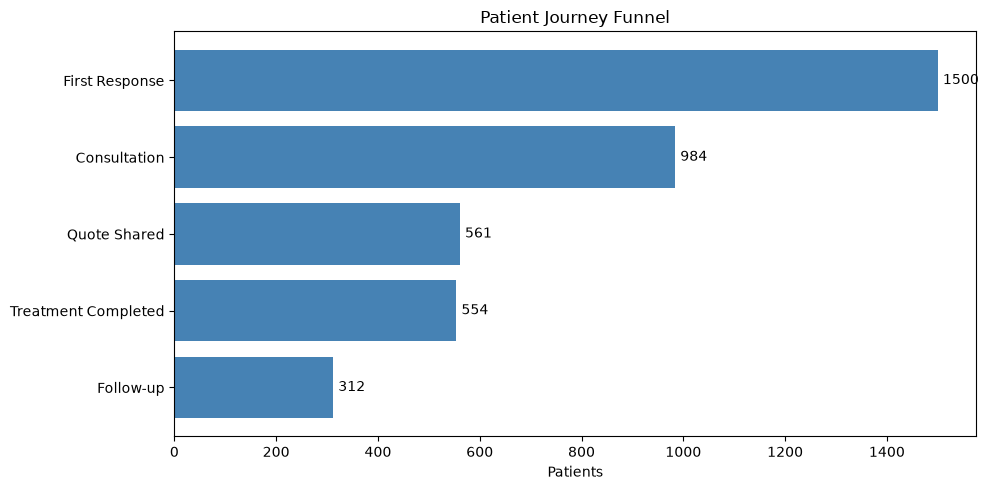

In [107]:
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(df_funnel['stage'], df_funnel['patient_count'], color='steelblue')

ax.invert_yaxis()  #first stage is on top

for i, v in enumerate(df_funnel['patient_count']):
    ax.text(v + 10, i, str(v), va='center')
    
ax.set_xlabel('Patients')
ax.set_title('Patient Journey Funnel')

plt.tight_layout()
plt.show()

### Provider Performence

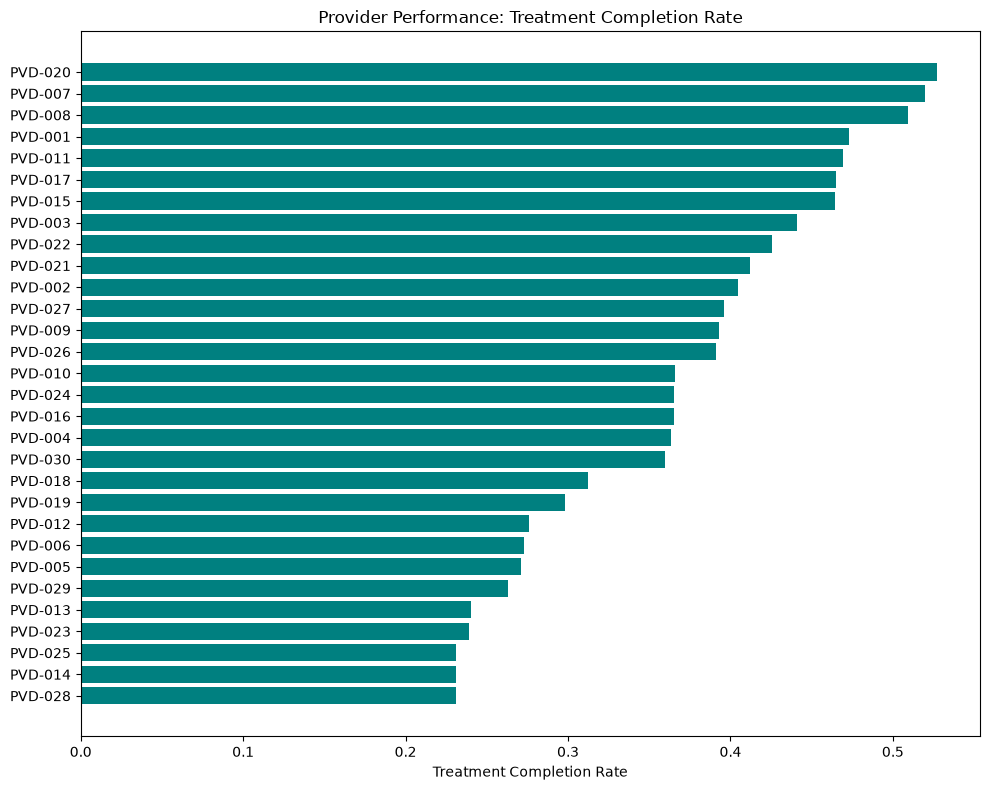

In [109]:
fig, ax = plt.subplots(figsize=(10,8))

provider_perf_sorted = provider_perf.sort_values('treatment_rate')

ax.barh(provider_perf_sorted.index, provider_perf_sorted['treatment_rate'], color='teal')

ax.set_xlabel('Treatment Completion Rate')
ax.set_title('Provider Performance: Treatment Completion Rate')

plt.tight_layout()
plt.show()

### SLA Breach Comperison

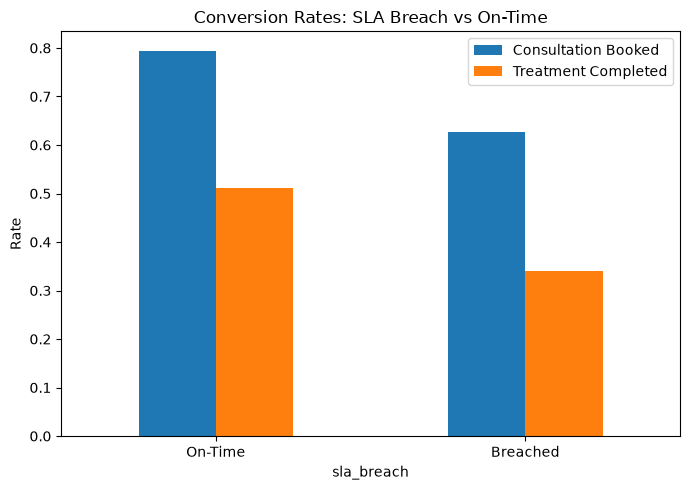

In [110]:
sla_summary = df.groupby('sla_breach')[['consultation_booked','treatment_completed']].mean()

sla_summary.plot(kind='bar', figsize=(7,5))
plt.title('Conversion Rates: SLA Breach vs On-Time')
plt.ylabel('Rate')
plt.xticks([0,1], ['On-Time', 'Breached'], rotation=0)
plt.legend(['Consultation Booked', 'Treatment Completed'])
plt.tight_layout()
plt.show()

### Response Time Distribution

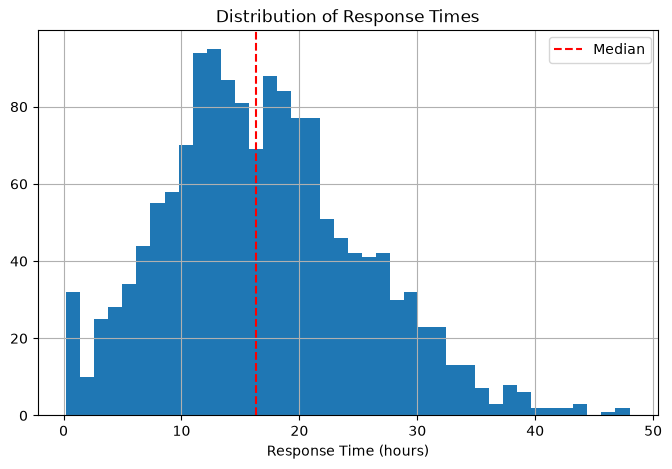

In [111]:
df['response_time_hours'].hist(bins=40, figsize=(8,5))
plt.axvline(df['response_time_hours'].median(), color='red', linestyle='--', label='Median')
plt.xlabel('Response Time (hours)')
plt.title('Distribution of Response Times')
plt.legend()
plt.show()

### Urgency and Treatment Completion Rate

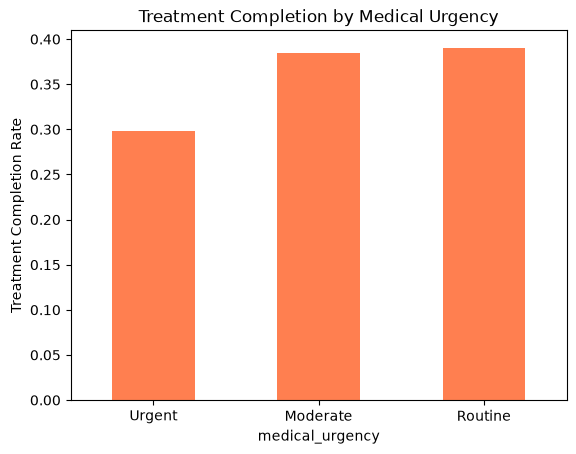

In [116]:
df.groupby('medical_urgency')['treatment_completed'].mean().sort_values().plot(kind='bar', color='coral')
plt.ylabel('Treatment Completion Rate')
plt.title('Treatment Completion by Medical Urgency')
plt.xticks(rotation=0)
plt.show()